<a href="https://colab.research.google.com/github/The9coder/dl-public-health-chatbot/blob/main/eda_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset download

Dataset:Symptoms to Diseases

Source:kaggle

In [5]:
!pip install --upgrade kaggle

In [ ]:
from google.colab import files
files.upload()

In [30]:
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [14]:
# Download the Kaggle dataset
!kaggle datasets download -d niyarrbarman/symptom2disease

Dataset URL: https://www.kaggle.com/datasets/niyarrbarman/symptom2disease
License(s): CC0-1.0
100% 43.6k/43.6k [00:00<00:00, 53.4MB/s]



In [15]:
# Unzip the downloaded dataset
!unzip -o symptom2disease.zip

# List files to confirm extraction
!ls

Archive:  symptom2disease.zip
  inflating: Symptom2Disease.csv     
sample_data  Symptom2Disease.csv  symptom2disease.zip


In [8]:
!ls

kaggle.json  sample_data


In [20]:
# =========================
# 1. Imports
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split

# Optional: download stopwords if not already
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [17]:
# =========================
# 2. Data Ingestion
# =========================
def load_dataset(path):
    df = pd.read_csv(path)   # adjust if JSON or Excel
    print("Dataset shape:", df.shape)
    print(df.head())
    return df

# Example usage
df = load_dataset("/content/Symptom2Disease.csv")


Dataset shape: (1200, 3)
   Unnamed: 0      label                                               text
0           0  Psoriasis  I have been experiencing a skin rash on my arm...
1           1  Psoriasis  My skin has been peeling, especially on my kne...
2           2  Psoriasis  I have been experiencing joint pain in my fing...
3           3  Psoriasis  There is a silver like dusting on my skin, esp...
4           4  Psoriasis  My nails have small dents or pits in them, and...


In [21]:
# =========================
# 3. Preprocessing
# =========================
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)   # remove punctuation/numbers
    tokens = text.split()
    tokens = [w for w in tokens if w not in stopwords.words('english')]
    return " ".join(tokens)

df['clean_text'] = df['text'].apply(clean_text)   # replace 'text_column' with actual column name


In [23]:
# =========================
# 4. Train/Val/Test Split
# =========================
X = df['clean_text']
y = df['label']   # replace with actual label column

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("Train size:", len(X_train))
print("Val size:", len(X_val))
print("Test size:", len(X_test))


Train size: 960
Val size: 120
Test size: 120


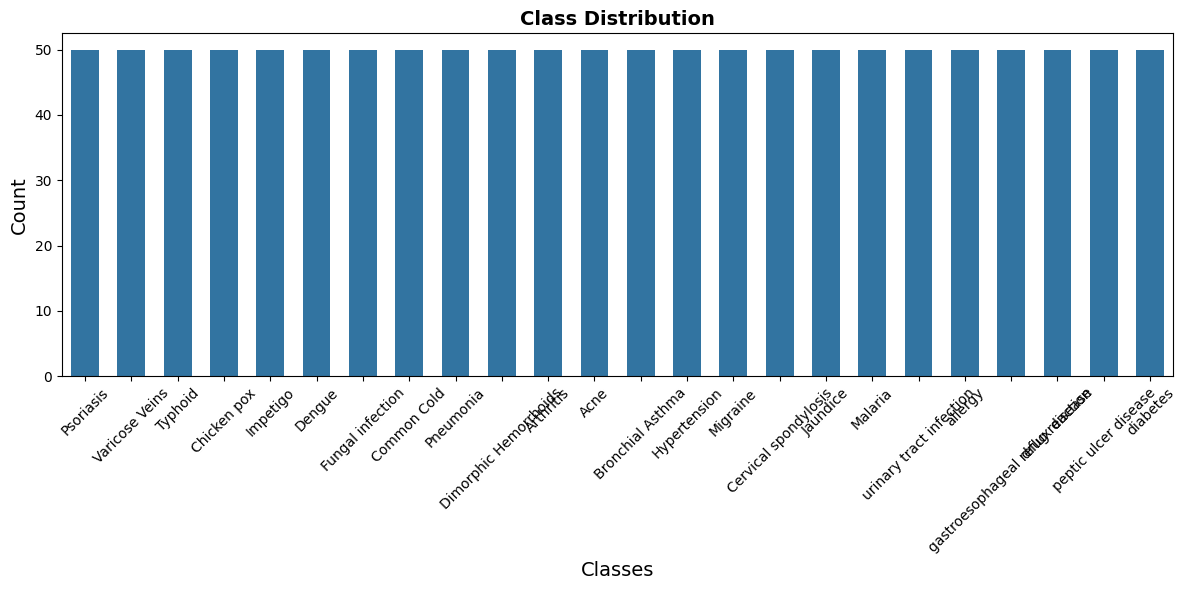

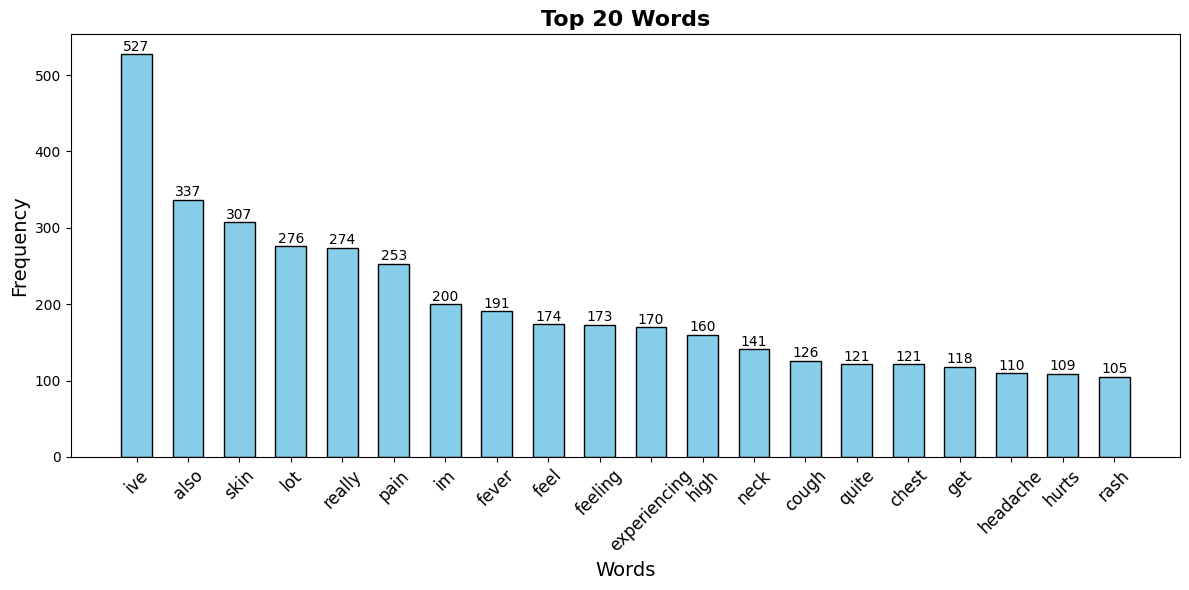

In [28]:
# =========================
# 5. Exploratory Data Analysis
# =========================
# Class distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.countplot(x=y, width=0.6)
plt.title("Class Distribution", fontsize=14, weight='bold')
plt.xlabel("Classes", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xticks(rotation=45)   # rotate labels if they overlap
plt.tight_layout()
plt.show()


# Word frequency visualization
from collections import Counter
all_words = "  ".join(X_train).split()
word_freq = Counter(all_words).most_common(20)

words = [w for w,_ in word_freq]
counts = [c for _,c in word_freq]

plt.figure(figsize=(12,6))
plt.bar(words, counts, width=0.6, color="skyblue", edgecolor="black")
plt.xticks(rotation=45, fontsize=12)
plt.title("Top 20 Words", fontsize=16, weight='bold')
plt.xlabel("Words", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
for i, c in enumerate(counts):
    plt.text(i, c+0.5, str(c), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()
